In [2]:
import random
#A list of integers
#Output: a permutation of those integers indexed by zero
def j_perm(li):
    if 0 in li:
        return Permutation(li, check_input = False)
    else:
        return Permutation([x-1 for x in li], check_input = False)
    
    
#Input: accepts a list of ordered pairs of the form [integer,[list of integers]].
#Output: the lists within converted to fuzzy perm matrices.
def list_to_perm_matrix(li):
    new_li = li
    n = len(li[0][1])
    for pair in li:
        pair[1] = genPermMatrix(j_perm(pair[1]),n)
    return new_li
        
#Input: a permutation p and an integer n.
#Output: Create the fuzzy permutation matrix of p raised to size n
def genPermMatrix(p,n):
    k = len(p)
    if k==n:
        return matrix(QQ,n,n, lambda x,y : p[x] == y)
    return factorial(n-k)/binomial(n,k)*matrix(n,n,lambda x,y:sum([binomial(x,j)*binomial(n-1-x,k-1-j)*binomial(y,p[j])*binomial(n-1-y,k-1-p[j]) for j in range(k)]))
                                                                                       
#This is the same as the above function except with the optional arguement
#of m and k which allow you to generate only part of a fuzzy matrix. Seems unneccesary to have both.                                               
def genPermMatrixByRow(p,n,m=None,k=None):
    if m==None:
        m=n
    l=len(p)
    if k==None:
        k=l
    if l==n:
        return matrix(QQ,m,n,lambda x,y:p[x]==y)
    return factorial(n-k)/binomial(n,k)*matrix(m,n,lambda x,y:sum([binomial(x,j)*binomial(n-1-x,k-1-j)*binomial(y,p[j])*binomial(n-1-y,k-1-p[j]) for j in range(l)]))
    
    
def vanCoverIsland(n):
    all_partitions = []
    for i in range(n+1):
        all_partitions += Partitions(i, min_length=2, min_part=2).list()
    
    random_partition = all_partitions[random.randrange(0,len(all_partitions))]
    
    available_ints = list(range(1,n+1))
    print(random_partition)
    for part in random_partition:
        chosen_ints = []
        for i in range(part):
            chosen_ints.append(available_ints[random.randrange(0,len(available_ints))])
            available_ints.remove(chosen_ints[i])
        print(Permutation(chosen_ints, check_input= False))
            
    return all_partitions

In [2]:
vanCoverIsland(8)

[3, 3, 2]
[4, 8, 1]
[2, 7, 3]
[5, 6]


[[2, 2],
 [3, 2],
 [4, 2],
 [3, 3],
 [2, 2, 2],
 [5, 2],
 [4, 3],
 [3, 2, 2],
 [6, 2],
 [5, 3],
 [4, 4],
 [4, 2, 2],
 [3, 3, 2],
 [2, 2, 2, 2]]

In [2]:
p564312 = j_perm([5,6,4,3,1,2])
p563412 = j_perm([5,6,3,4,1,2])
p6734512 = j_perm([6,7,3,4,5,1,2])
p6754312 = j_perm([6,7,5,4,3,1,2])
x = 16/7
m1 = genPermMatrix(p564312,7) 
m2 = genPermMatrix(p563412,7) 
m3 = genPermMatrix(p6734512,7) 
m4 = genPermMatrix(p6754312,7)

print(m1)
print()
print(m2)
print()
print(m3)
print()
print(m4)


m1 - m2 + x*(m3-m4)

[   0    0    0    0 12/7 30/7    0]
[   0    0    0    0  2/7 10/7 30/7]
[   0    0    0 12/7 16/7  2/7 12/7]
[   0    0 12/7 18/7 12/7    0    0]
[12/7  2/7 16/7 12/7    0    0    0]
[30/7 10/7  2/7    0    0    0    0]
[   0 30/7 12/7    0    0    0    0]

[   0    0    0    0 12/7 30/7    0]
[   0    0    0    0  2/7 10/7 30/7]
[   0    0 16/7 12/7    0  2/7 12/7]
[   0    0 12/7 18/7 12/7    0    0]
[12/7  2/7    0 12/7 16/7    0    0]
[30/7 10/7  2/7    0    0    0    0]
[   0 30/7 12/7    0    0    0    0]

[0 0 0 0 0 1 0]
[0 0 0 0 0 0 1]
[0 0 1 0 0 0 0]
[0 0 0 1 0 0 0]
[0 0 0 0 1 0 0]
[1 0 0 0 0 0 0]
[0 1 0 0 0 0 0]

[0 0 0 0 0 1 0]
[0 0 0 0 0 0 1]
[0 0 0 0 1 0 0]
[0 0 0 1 0 0 0]
[0 0 1 0 0 0 0]
[1 0 0 0 0 0 0]
[0 1 0 0 0 0 0]


[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]

In [10]:
#1*(4321) -4/5*(45321) -6/5*(53421) -6/5*(54231) -4/5*(54312)

p1 = j_perm([4,3,2,1])
p2 = j_perm([4,5,3,2,1])
p3 = j_perm([5,3,4,2,1])
p4 = j_perm([5,4,2,3,1])
p5 = j_perm([5,4,3,1,2])

m1 = genPermMatrix(p1,5)
m2 = genPermMatrix(p2,5)
m3 = genPermMatrix(p3,5)
m4 = genPermMatrix(p4,5)
m5 = genPermMatrix(p5,5)

print(m1)
print()
print(m2)
print()
print(m3)
print()
print(m4)
print()
print(m5)
print()
rho = 1*m1 - 4/5*m2 - 6/5*m3 - 6/5*m4 - 4/5*m5
print(rho)
print()
print(rho-m1)

[   0    0    0  4/5 16/5]
[   0    0  6/5    2  4/5]
[   0  6/5  8/5  6/5    0]
[ 4/5    2  6/5    0    0]
[16/5  4/5    0    0    0]

[0 0 0 1 0]
[0 0 0 0 1]
[0 0 1 0 0]
[0 1 0 0 0]
[1 0 0 0 0]

[0 0 0 0 1]
[0 0 1 0 0]
[0 0 0 1 0]
[0 1 0 0 0]
[1 0 0 0 0]

[0 0 0 0 1]
[0 0 0 1 0]
[0 1 0 0 0]
[0 0 1 0 0]
[1 0 0 0 0]

[0 0 0 0 1]
[0 0 0 1 0]
[0 0 1 0 0]
[1 0 0 0 0]
[0 1 0 0 0]

[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]

[    0     0     0  -4/5 -16/5]
[    0     0  -6/5    -2  -4/5]
[    0  -6/5  -8/5  -6/5     0]
[ -4/5    -2  -6/5     0     0]
[-16/5  -4/5     0     0     0]


In [4]:
p = j_perm([1,2])
matrix12upto3 = genPermMatrix(p,5)
matrix21upto3 = genPermMatrix(j_perm([2,1]),5)

nu = matrix12upto3 + matrix21upto3
print(nu)

p123 = j_perm([1,2,3])
matrix123upto3 = genPermMatrix(p123,3)
p321 = j_perm([3,2,1])
matrix321upto3 = genPermMatrix(p321,3)

zeta = 2*matrix123upto3 - 2*matrix321upto3 -3*matrix12upto3
print(zeta)

[48/5 48/5 48/5 48/5 48/5]
[48/5 48/5 48/5 48/5 48/5]
[48/5 48/5 48/5 48/5 48/5]
[48/5 48/5 48/5 48/5 48/5]
[48/5 48/5 48/5 48/5 48/5]


TypeError: unsupported operand parent(s) for -: 'Full MatrixSpace of 3 by 3 dense matrices over Rational Field' and 'Full MatrixSpace of 5 by 5 dense matrices over Rational Field'

In [6]:
p123 = j_perm([1,2,3])
p321 = j_perm([3,2,1])
p12 = j_perm([1,2])
m123up3 = genPermMatrix(p123,3)
m321up3 = genPermMatrix(p321,3)
m12up3 = genPermMatrix(p12,3)
m21up3 = genPermMatrix(j_perm([2,1]),3)


print(-2*m321up3 + 2*m123up3 -3/2*m12up3 +3/2*m21up3)
print(m12up3 + m21up3)

print(2*m123)

genPermMatrixImage(genPermMatrix(j_perm([1,2]),3))


[0 0 0]
[0 0 0]
[0 0 0]
[4/3 4/3 4/3]
[4/3 4/3 4/3]
[4/3 4/3 4/3]


NameError: name 'm123' is not defined

In [5]:
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image as im

#we want a 
def genPermMatrixImage(p):
    plt.style.use('grayscale')
    image_dim = 64
    array = p.numpy()
    array = array/array.max()
    array = 1-array
    
    plt.xticks([])
    plt.yticks([])
    plt.imshow(np.kron(array, np.ones((image_dim,image_dim))))
    plt.show()
    
    
def downloadPermMatrixImage(p,title):
    plt.style.use('grayscale')
    image_dim = 64
    array = p.numpy()
    array = array/array.max()
    array = 1-array
    
    plt.xticks([])
    plt.yticks([])
    plt.imshow(np.kron(array, np.ones((image_dim,image_dim))))
    plt.savefig(title)
    
p123 = j_perm([3,4,2,5,1])
matrix123upto4 = genPermMatrix(p123,6)
#genPermMatrixImage(matrix123upto4)

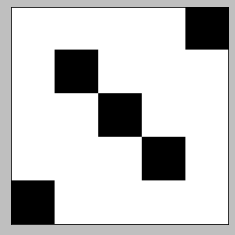

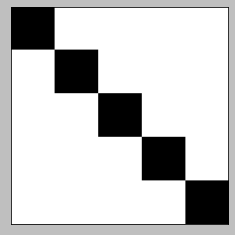

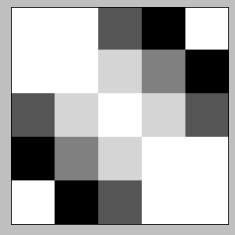

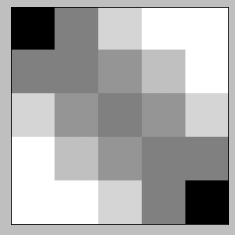

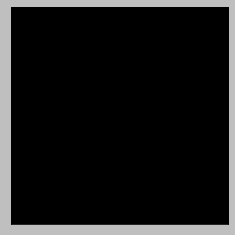

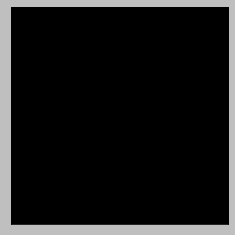

In [6]:
p1 = genPermMatrix(j_perm([1,2,3]),5)
p2 = genPermMatrix(j_perm([3,4,1,2]),5)
p3 = genPermMatrix(j_perm([1,2,3,4,5]),5)
p4 = genPermMatrix(j_perm([5,2,3,4,1]),5)

genPermMatrixImage(p4)
genPermMatrixImage(p3)
genPermMatrixImage(p2)
genPermMatrixImage(p1)
genPermMatrixImage((10*p1 + 15*p2-36*p3+36*p4))

downloadPermMatrixImage(p4,"p52341.png")
downloadPermMatrixImage(p3,"p12345.png")
downloadPermMatrixImage(p2,"p3421.png")
downloadPermMatrixImage(p1,"p123.png")
downloadPermMatrixImage((10*p1 + 15*p2-36*p3+36*p4),"pSUM.png")

In [34]:
#list of lists which contain tuples of coefficient and permutation
L2_atomics = [
    [[1,[1,2]],[1,[2,1]]]
]

L3_atomics = [
    [[2,[1,2,3]],
    [-2,[3,2,1]],
    [-3,[1,2]]]
]

L4_atomics = [
    [
        [3,[3,1,4,2]],[3,[2,4,1,3]],[2,[3,2,1]],[2,[1,2,3]]
    ],
    [
        [3,[3,4,1,2]],[3,[2,1,4,3]],[2,[3,2,1]],[2,[1,2,3]]
    ],
    [
        [-3,[4,2,3,1]],[-3,[1,3,2,4]],[2,[3,2,1]],[2,[1,2,3]]
    ],
    [
        [-3,[4,3,2,1]],[-3,[1,2,3,4]],[2,[3,2,1]],[2,[1,2,3]]
    ],
    
    [
       [36,[5,2,3,4,1]],[-36,[1,2,3,4,5]],[15,[3,4,1,2]],[10,[1,2,3]] 
    ],
    
    [
       [36,[5,2,4,3,1]],[-36,[1,2,4,3,5]],[15,[3,4,1,2]],[10,[1,2,3]] 
    ]
]

L5_to_check =[
        [[-3,[2, 0, 3, 1]], [-3,[1, 3, 0, 2]], [4,[1, 0, 2]], [4,[0, 2, 1]], [3,[1, 0]]],
    [[-3,[2, 3, 0, 1]], [-3,[1, 0, 3, 2]], [4,[1, 0, 2]], [4,[0, 2, 1]], [3,[1, 0]]],
    [[3,[3, 1, 2, 0]], [3,[0, 2, 1, 3]], [4,[1, 0, 2]], [4,[0, 2, 1]], [-3,[0, 1]]],
    [[3,[3, 1, 2, 0]], [3,[0, 2, 1, 3]], [4,[1, 0, 2]], [4,[0, 2, 1]], [3,[1, 0]]],
    [[3,[3, 2, 1, 0]], [3,[0, 1, 2, 3]], [4,[1, 0, 2]], [4,[0, 2, 1]], [-3,[0, 1]]],
    [[3,[3, 2, 1, 0]], [3,[0, 1, 2, 3]], [4,[1, 0, 2]], [4,[0, 2, 1]], [3,[1, 0]]],
    [[3,[3, 1, 2, 0]], [3,[0, 2, 1, 3]], [2,[1, 0, 2]], [2,[0, 2, 1]], [-2,[0, 1, 2]]],
    [[3,[3, 2, 1, 0]], [3,[0, 1, 2, 3]], [2,[1, 0, 2]], [2,[0, 2, 1]], [-2,[0, 1, 2]]],
    [[-3,[1, 0, 3, 2]], [-4,[0, 2, 1, 3]], [-5,[0, 1, 2, 3]], [4,[2, 1, 0]], [6,[0, 1]]],
    [[3,[1, 0, 3, 2]], [4,[0, 2, 1, 3]], [5,[0, 1, 2, 3]], [-4,[2, 1, 0]], [6,[1, 0]]],
    [[3,[2, 3, 0, 1]], [-4,[0, 2, 1, 3]], [-5,[0, 1, 2, 3]], [8,[0, 1, 2]], [3,[1, 0]]],
    [[3,[2, 3, 0, 1]], [-4,[0, 2, 1, 3]], [-5,[0, 1, 2, 3]], [8,[2, 1, 0]], [9,[0, 1]]],
    [[-3,[2, 3, 0, 1]], [4,[0, 2, 1, 3]], [5,[0, 1, 2, 3]], [-8,[2, 1, 0]], [9,[1, 0]]],
    [[12,[3, 1, 2, 0]], [-9,[1, 0, 3, 2]], [-15,[0, 1, 2, 3]], [-4,[0, 1, 2]], [12,[0, 1]]],
    [[-12,[3, 1, 2, 0]], [9,[1, 0, 3, 2]], [15,[0, 1, 2, 3]], [4,[0, 1, 2]], [12,[1, 0]]],
    [[12,[3, 1, 2, 0]], [-9,[1, 0, 3, 2]], [-15,[0, 1, 2, 3]], [-4,[2, 1, 0]], [6,[0, 1]]],
    [[-12,[3, 1, 2, 0]], [9,[1, 0, 3, 2]], [15,[0, 1, 2, 3]], [4,[2, 1, 0]], [6,[1, 0]]],
    [[12,[3, 1, 2, 0]], [9,[2, 3, 0, 1]], [-15,[0, 1, 2, 3]], [8,[0, 1, 2]], [3,[0, 1]]],
    [[12,[3, 1, 2, 0]], [9,[2, 3, 0, 1]], [-15,[0, 1, 2, 3]], [8,[0, 1, 2]], [-3,[1, 0]]],
    [[12,[3, 1, 2, 0]], [9,[2, 3, 0, 1]], [-15,[0, 1, 2, 3]], [8,[2, 1, 0]], [15,[0, 1]]],
    [[-12,[3, 1, 2, 0]], [-9,[2, 3, 0, 1]], [15,[0, 1, 2, 3]], [-8,[2, 1, 0]], [15,[1, 0]]],
    [[3,[1, 0, 3, 2]], [4,[0, 2, 1, 3]], [5,[0, 1, 2, 3]], [4,[2, 0, 1]], [4,[1, 2, 0]]],
    [[3,[2, 3, 0, 1]], [-4,[0, 2, 1, 3]], [-5,[0, 1, 2, 3]], [2,[2, 1, 0]], [6,[0, 1, 2]]],
    [[-12,[3, 1, 2, 0]], [9,[1, 0, 3, 2]], [15,[0, 1, 2, 3]], [8,[2, 1, 0]], [-4,[0, 1, 2]]],
    [[12,[3, 1, 2, 0]], [9,[2, 3, 0, 1]], [-15,[0, 1, 2, 3]], [-2,[2, 1, 0]], [10,[0, 1, 2]]],
    [[3,[2, 3, 0, 1]], [6,[1, 0, 3, 2]], [4,[0, 2, 1, 3]], [5,[0, 1, 2, 3]], [3,[1, 0]]],
    [[3,[3, 1, 2, 0]], [-3,[1, 0, 3, 2]], [-1,[0, 2, 1, 3]], [-5,[0, 1, 2, 3]], [3,[0, 1]]],
    [[-3,[3, 1, 2, 0]], [3,[1, 0, 3, 2]],  [1,[0, 2, 1, 3]], [5,[0, 1, 2, 3]], [3,[1, 0]]],
    [[6,[3, 1, 2, 0]], [3,[2, 3, 0, 1]], [2,[0, 2, 1, 3]], [-5,[0, 1, 2, 3]], [3,[0, 1]]],
    [[-6,[3, 1, 2, 0]], [-3,[2, 3, 0, 1]], [-2,[0, 2, 1, 3]], [5,[0, 1, 2, 3]], [3,[1, 0]]],
    [[4,[3, 1, 2, 0]],  [1,[2, 3, 0, 1]], [-2,[1, 0, 3, 2]], [-5,[0, 1, 2, 3]], [3,[0, 1]]],
    [[-4,[3, 1, 2, 0]], [-1,[2, 3, 0, 1]], [2,[1, 0, 3, 2]], [5,[0, 1, 2, 3]], [3,[1, 0]]],
    [[3,[3, 2, 1, 0]], [-3,[1, 0, 3, 2]], [-4,[0, 2, 1, 3]], [-2,[0, 1, 2, 3]], [3,[0, 1]]],
    [[-3,[3, 2, 1, 0]], [3,[1, 0, 3, 2]], [4,[0, 2, 1, 3]], [2,[0, 1, 2, 3]], [3,[1, 0]]],
    [[6,[3, 2, 1, 0]], [3,[2, 3, 0, 1]], [-4,[0, 2, 1, 3]],  [1,[0, 1, 2, 3]], [3,[0, 1]]],
    [[-6,[3, 2, 1, 0]], [-3,[2, 3, 0, 1]], [4,[0, 2, 1, 3]], [-1,[0, 1, 2, 3]], [3,[1, 0]]],
    [[6,[2, 3, 0, 1]], [9,[1, 0, 3, 2]], [4,[0, 2, 1, 3]], [5,[0, 1, 2, 3]], [4,[2, 1, 0]]],
    [[-6,[3, 1, 2, 0]], [3,[1, 0, 3, 2]], [-2,[0, 2, 1, 3]], [5,[0, 1, 2, 3]], [4,[2, 1, 0]]],
    [[3,[3, 1, 2, 0]], [3,[2, 3, 0, 1]], [-1,[0, 2, 1, 3]], [-5,[0, 1, 2, 3]], [4,[0, 1, 2]]],
    [[-4,[3, 1, 2, 0]], [2,[2, 3, 0, 1]], [5,[1, 0, 2, 3]], [5,[0, 1, 3, 2]], [4,[2, 1, 0]]],
    [[4,[3, 1, 2, 0]], [4,[2, 3, 0, 1]],  [1,[1, 0, 3, 2]], [-5,[0, 1, 2, 3]], [4,[0, 1, 2]]],
    [[-4,[3, 1, 2, 0]], [2,[2, 3, 0, 1]], [5,[1, 0, 3, 2]], [5,[0, 1, 2, 3]], [4,[2, 1, 0]]],
    [[3,[3, 2, 0, 1]], [3,[2, 3, 1, 0]], [-4,[0, 2, 1, 3]], [-2,[0, 1, 2, 3]], [4,[0, 1, 2]]],
    [[-6,[3, 2, 1, 0]], [3,[1, 0, 3, 2]], [4,[0, 2, 1, 3]], [-1,[0, 1, 2, 3]], [4,[2, 1, 0]]],
    [[3,[3, 2, 1, 0]], [3,[2, 3, 0, 1]], [-4,[0, 2, 1, 3]], [-2,[0, 1, 2, 3]], [4,[0, 1, 2]]],
    [[36,[3, 0, 2, 4, 1]], [-36,[1, 4, 2, 0, 3]], [30,[1, 3, 0, 2]], [20,[0, 1, 2]], [15,[1, 0]]],
    [[36,[4, 1, 2, 3, 0]], [-36,[0, 1, 2, 3, 4]], [-15,[1, 0, 3, 2]], [-10,[0, 1, 2]], [15,[0, 1]]],
    [[-36,[4, 1, 2, 3, 0]], [36,[0, 1, 2, 3, 4]], [15,[1, 0, 3, 2]], [10,[0, 1, 2]], [15,[1, 0]]],
    [[36,[4, 1, 2, 3, 0]], [-36,[0, 1, 2, 3, 4]], [15,[2, 3, 0, 1]], [10,[2, 1, 0]], [15,[0, 1]]],
    [[-36,[4, 1, 2, 3, 0]], [36,[0, 1, 2, 3, 4]], [-15,[2, 3, 0, 1]], [-10,[2, 1, 0]], [15,[1, 0]]],
    [[36,[4, 1, 3, 2, 0]], [-36,[0, 1, 3, 2, 4]], [-15,[1, 0, 3, 2]], [-10,[0, 1, 2]], [15,[0, 1]]],
    [[-36,[4, 1, 3, 2, 0]], [36,[0, 1, 3, 2, 4]], [15,[1, 0, 3, 2]], [10,[0, 1, 2]], [15,[1, 0]]],
    [[36,[4, 1, 3, 2, 0]], [-36,[0, 1, 3, 2, 4]], [15,[2, 3, 0, 1]], [10,[2, 1, 0]], [15,[0, 1]]],
    [[-36,[4, 1, 3, 2, 0]], [36,[0, 1, 3, 2, 4]], [-15,[2, 3, 0, 1]], [-10,[2, 1, 0]], [15,[1, 0]]],
    [[12,[4, 3, 2, 1, 0]], [-12,[0, 1, 2, 3, 4]], [15,[0, 1, 2, 3]], [-10,[0, 1, 2]], [5,[0, 1]]],
    [[-12,[4, 3, 2, 1, 0]], [12,[0, 1, 2, 3, 4]], [-15,[0, 1, 2, 3]], [10,[0, 1, 2]], [5,[1, 0]]],
    [[-12,[4, 3, 2, 1, 0]], [12,[0, 1, 2, 3, 4]], [-15,[0, 1, 2, 3]], [10,[2, 1, 0]], [10,[0, 1]]],
    [[12,[4, 3, 2, 1, 0]], [-12,[0, 1, 2, 3, 4]], [15,[0, 1, 2, 3]], [-10,[2, 1, 0]], [10,[1, 0]]],
    [[18,[3, 0, 2, 4, 1]], [-18,[1, 4, 2, 0, 3]], [15,[1, 3, 0, 2]], [5,[2, 1, 0]], [5,[0, 1, 2]]],
    [[36,[4, 1, 2, 3, 0]], [-36,[0, 1, 2, 3, 4]], [-15,[1, 0, 3, 2]], [10,[1, 0, 2]], [10,[0, 2, 1]]],
    [[-36,[4, 1, 2, 3, 0]], [36,[0, 1, 2, 3, 4]], [-15,[2, 3, 0, 1]], [10,[2, 0, 1]], [10,[1, 2, 0]]],
    [[36,[4, 1, 3, 2, 0]], [-36,[0, 1, 3, 2, 4]], [-15,[1, 0, 3, 2]], [10,[1, 0, 2]], [10,[0, 2, 1]]],
    [[-36,[4, 1, 3, 2, 0]], [36,[0, 1, 3, 2, 4]], [-15,[2, 3, 0, 1]], [10,[2, 0, 1]], [10,[1, 2, 0]]],
    [[-36,[4, 3, 2, 1, 0]], [36,[0, 1, 2, 3, 4]], [-45,[0, 1, 2, 3]], [10,[2, 1, 0]], [20,[0, 1, 2]]],
    [[-24,[3, 4, 2, 0, 1]], [24,[1, 0, 2, 4, 3]], [15,[2, 1, 0, 3]], [15,[0, 3, 2, 1]], [5,[1, 0]]],
    [[-24,[3, 4, 2, 0, 1]], [24,[1, 0, 2, 4, 3]], [15,[2, 3, 0, 1]], [15,[0, 1, 2, 3]], [5,[1, 0]]],
    [[24,[4, 1, 2, 3, 0]], [-24,[0, 1, 2, 3, 4]], [5,[2, 3, 0, 1]], [-5,[1, 0, 3, 2]], [5,[0, 1]]],
    [[-24,[4, 1, 2, 3, 0]], [24,[0, 1, 2, 3, 4]], [-5,[2, 3, 0, 1]], [5,[1, 0, 3, 2]], [5,[1, 0]]],
    [[24,[4, 1, 3, 2, 0]], [-24,[0, 1, 3, 2, 4]], [5,[2, 3, 0, 1]], [-5,[1, 0, 3, 2]], [5,[0, 1]]],
    [[-24,[4, 1, 3, 2, 0]], [24,[0, 1, 3, 2, 4]], [-5,[2, 3, 0, 1]], [5,[1, 0, 3, 2]], [5,[1, 0]]],
    [[-24,[4, 3, 2, 1, 0]], [24,[0, 1, 2, 3, 4]], [15,[3, 2, 1, 0]], [-15,[0, 1, 2, 3]], [5,[0, 1]]],
    [[-36,[4, 3, 2, 1, 0]], [36,[0, 1, 2, 3, 4]], [15,[3, 2, 1, 0]], [-30,[0, 1, 2, 3]], [10,[0, 1, 2]]],
    [[12,[3, 0, 2, 4, 1]], [-12,[1, 4, 2, 0, 3]], [5,[3, 1, 2, 0]], [10,[1, 3, 0, 2]], [5,[0, 2, 1, 3]]],
    [[12,[3, 0, 2, 4, 1]], [-12,[1, 4, 2, 0, 3]], [5,[3, 2, 1, 0]], [10,[1, 3, 0, 2]], [5,[0, 1, 2, 3]]]
]

The plan:
    We have the set of length 5 terms to search.
    Now we need to write a function to convert them into permutations
    Then we create matrices.
    Then we have n^2 linear equations and see if a solution exists
    Maintain a set of atomics.
     Using linear algebra somehow, we compute if a given cover can be represented as a linear combo of atomics.
     If yes, ignore it.
     If no, add it to list of atomics. 
     

In [28]:
import re

with open('length_5_constant_covers.txt', 'r') as file:
    # Read each line in the file
    
    
    
    pattern = r"-?\d+,\s*\[.*?\]"
    output_string = ""
    for line in file:
        if "HARK" in line:
            break
        line = line.strip()
        result = re.sub(pattern, lambda match: f"[{match.group(0)}],", line)
        output_string += result[0:-2]+"]\n" 
print(output_string)

[[-3,[2, 0, 3, 1]], [-3,[1, 3, 0, 2]], +[4,[1, 0, 2]], +[4,[0, 2, 1]], +[3,[1, 0]]]
[[-3,[2, 3, 0, 1]], [-3,[1, 0, 3, 2]], +[4,[1, 0, 2]], +[4,[0, 2, 1]], +[3,[1, 0]]]
[[3,[3, 1, 2, 0]], +[3,[0, 2, 1, 3]], +[4,[1, 0, 2]], +[4,[0, 2, 1]], [-3,[0, 1]]]
[[3,[3, 1, 2, 0]], +[3,[0, 2, 1, 3]], +[4,[1, 0, 2]], +[4,[0, 2, 1]], +[3,[1, 0]]]
[[3,[3, 2, 1, 0]], +[3,[0, 1, 2, 3]], +[4,[1, 0, 2]], +[4,[0, 2, 1]], [-3,[0, 1]]]
[[3,[3, 2, 1, 0]], +[3,[0, 1, 2, 3]], +[4,[1, 0, 2]], +[4,[0, 2, 1]], +[3,[1, 0]]]
[[3,[3, 1, 2, 0]], +[3,[0, 2, 1, 3]], +[2,[1, 0, 2]], +[2,[0, 2, 1]], [-2,[0, 1, 2]]]
[[3,[3, 2, 1, 0]], +[3,[0, 1, 2, 3]], +[2,[1, 0, 2]], +[2,[0, 2, 1]], [-2,[0, 1, 2]]]
[[-3,[1, 0, 3, 2]], [-4,[0, 2, 1, 3]], [-5,[0, 1, 2, 3]], +[4,[2, 1, 0]], +[6,[0, 1]]]
[[3,[1, 0, 3, 2]], +[4,[0, 2, 1, 3]], +[5,[0, 1, 2, 3]], [-4,[2, 1, 0]], +[6,[1, 0]]]
[[3,[2, 3, 0, 1]], [-4,[0, 2, 1, 3]], [-5,[0, 1, 2, 3]], +[8,[0, 1, 2]], +[3,[1, 0]]]
[[3,[2, 3, 0, 1]], [-4,[0, 2, 1, 3]], [-5,[0, 1, 2, 3]], +[8,[2, 1, 0

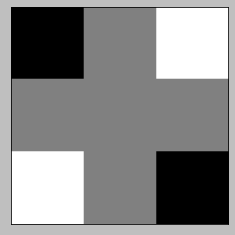

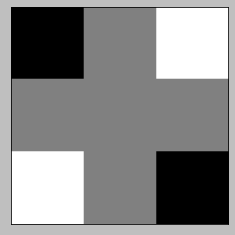

In [11]:
p = genPermMatrix(j_perm([1,2]),3)
genPermMatrixImage(p)
downloadPermMatrixImage(p,"p12upto3.png")